# Cleaning


In [1]:
import pandas as pd
import matplotlib as mlp
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("datasets/fifa_eda_stats.csv") 

In [3]:
df.isnull().mean().sort_values(ascending=False)

Loaned From                 0.930576
Release Clause              0.085901
Joined                      0.085297
Contract Valid Until        0.015873
Club                        0.013237
Jersey Number               0.003295
Position                    0.003295
Skill Moves                 0.002636
International Reputation    0.002636
Work Rate                   0.002636
Body Type                   0.002636
Weak Foot                   0.002636
Height                      0.002636
Weight                      0.002636
Crossing                    0.002636
Finishing                   0.002636
HeadingAccuracy             0.002636
Curve                       0.002636
BallControl                 0.002636
LongPassing                 0.002636
FKAccuracy                  0.002636
Volleys                     0.002636
Dribbling                   0.002636
ShortPassing                0.002636
Preferred Foot              0.002636
Strength                    0.002636
LongShots                   0.002636
I

In [4]:
df = df.drop(columns=['Loaned From'])

In [5]:
df['Joined'] = pd.to_datetime(df['Joined'], errors='coerce')
df['Contract Valid Until'] = pd.to_datetime(df['Contract Valid Until'], errors='coerce')

In [6]:
df['Joined'].head()

0   2004-07-01
1   2018-07-10
2   2017-08-03
3   2011-07-01
4   2015-08-30
Name: Joined, dtype: datetime64[ns]

In [7]:
def convert_currency(val):
    if isinstance(val, str):
        val = val.replace('€', '').replace('M', 'e6').replace('K', 'e3')
        try:
            return float(eval(val))
        except:
            return np.nan
    return val

for col in ['Value', 'Wage', 'Release Clause']:
    df[col] = df[col].apply(convert_currency)

df['Release Clause'] = df['Release Clause'].fillna(df['Release Clause'].median())

In [8]:
df.head()

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,110500000.0,565000.0,Left,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,226500000.0
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,77000000.0,405000.0,Right,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,127100000.0
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,118500000.0,290000.0,Right,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,228100000.0
3,193080,De Gea,27,Spain,91,93,Manchester United,72000000.0,260000.0,Right,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,138600000.0
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,102000000.0,355000.0,Right,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,196400000.0


In [9]:

def convert_height_in(x):
    if isinstance(x, str) and "'" in x:
        feet, inches = x.split("'")
        return int(feet) * 12 + int(inches)
    return np.nan

def convert_weight_lbs(x):
    if isinstance(x, str) and 'lbs' in x:
        return int(x.replace('lbs', '').strip())
    return np.nan
df['Height_in'] = df['Height'].apply(convert_height_in)
df['Weight_lbs'] = df['Weight'].apply(convert_weight_lbs)

df = df.drop(columns=['Height', 'Weight'])


In [10]:
df.head()

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,...,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause,Height_in,Weight_lbs
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,110500000.0,565000.0,Left,...,28.0,26.0,6.0,11.0,15.0,14.0,8.0,226500000.0,67.0,159.0
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,77000000.0,405000.0,Right,...,31.0,23.0,7.0,11.0,15.0,14.0,11.0,127100000.0,74.0,183.0
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,118500000.0,290000.0,Right,...,24.0,33.0,9.0,9.0,15.0,15.0,11.0,228100000.0,69.0,150.0
3,193080,De Gea,27,Spain,91,93,Manchester United,72000000.0,260000.0,Right,...,21.0,13.0,90.0,85.0,87.0,88.0,94.0,138600000.0,76.0,168.0
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,102000000.0,355000.0,Right,...,58.0,51.0,15.0,13.0,5.0,10.0,13.0,196400000.0,71.0,154.0


In [11]:
df['Club'] = df['Club'].fillna('Free Agent')

In [12]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 56 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   ID                        18207 non-null  int64         
 1   Name                      18207 non-null  object        
 2   Age                       18207 non-null  int64         
 3   Nationality               18207 non-null  object        
 4   Overall                   18207 non-null  int64         
 5   Potential                 18207 non-null  int64         
 6   Club                      18207 non-null  object        
 7   Value                     18207 non-null  float64       
 8   Wage                      18207 non-null  float64       
 9   Preferred Foot            18159 non-null  object        
 10  International Reputation  18159 non-null  float64       
 11  Weak Foot                 18159 non-null  float64       
 12  Skill Moves       

In [13]:
df.to_csv('cleaned.csv', index=False)

# Exploratory


In [ ]:
import pandas as pd
import matplotlib as mlp
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../f1data/fifa_eda_stats.csv") 


In [3]:
df.head()

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,€110.5M,€565K,Left,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,€77M,€405K,Right,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,€118.5M,€290K,Right,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,193080,De Gea,27,Spain,91,93,Manchester United,€72M,€260K,Right,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,€102M,€355K,Right,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 57 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        18207 non-null  int64  
 1   Name                      18207 non-null  object 
 2   Age                       18207 non-null  int64  
 3   Nationality               18207 non-null  object 
 4   Overall                   18207 non-null  int64  
 5   Potential                 18207 non-null  int64  
 6   Club                      17966 non-null  object 
 7   Value                     18207 non-null  object 
 8   Wage                      18207 non-null  object 
 9   Preferred Foot            18159 non-null  object 
 10  International Reputation  18159 non-null  float64
 11  Weak Foot                 18159 non-null  float64
 12  Skill Moves               18159 non-null  float64
 13  Work Rate                 18159 non-null  object 
 14  Body T

In [5]:
df.describe()

,ID,Age,Overall,Potential,International Reputation,Weak Foot,Skill Moves,Jersey Number,Crossing,Finishing,...,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes
count,18207.000000,18207.000000,18207.000000,18207.000000,18159.000000,18159.000000,18159.000000,18147.000000,18159.000000,18159.000000,...,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000
mean,214298.338606,25.122206,66.238699,71.307299,1.113222,2.947299,2.361308,19.546096,49.734181,45.550911,...,48.548598,58.648274,47.281623,47.697836,45.661435,16.616223,16.391596,16.232061,16.388898,16.710887
std,29965.244204,4.669943,6.908930,6.136496,0.394031,0.660456,0.756164,15.947765,18.364524,19.525820,...,15.704053,11.436133,19.904397,21.664004,21.289135,17.695349,16.906900,16.502864,17.034669,17.955119
min,16.000000,16.000000,46.000000,48.000000,1.000000,1.000000,1.000000,1.000000,5.000000,2.000000,...,5.000000,3.000000,3.000000,2.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,200315.500000,21.000000,62.000000,67.000000,1.000000,3.000000,2.000000,8.000000,38.000000,30.000000,...,39.000000,51.000000,30.000000,27.000000,24.000000,8.000000,8.000000,8.000000,8.000000,8.000000
50%,221759.000000,25.000000,66.000000,71.000000,1.000000,3.000000,2.000000,17.000000,54.000000,49.000000,...,49.000000,60.000000,53.000000,55.000000,52.000000,11.000000,11.000000,11.000000,11.000000,11.000000
75%,236529.500000,28.000000,71.000000,75.000000,1.000000,3.000000,3.000000,26.000000,64.000000,62.000000,...,60.000000,67.000000,64.000000,66.000000,64.000000,14.000000,14.000000,14.000000,14.000000,14.000000
max,246620.000000,45.000000,94.000000,95.000000,5.000000,5.000000,5.000000,99.000000,93.000000,95.000000,...,92.000000,96.000000,94.000000,93.000000,91.000000,90.000000,92.000000,91.000000,90.000000,94.000000


array([[<Axes: title={'center': 'ID'}>, <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Overall'}>,
        <Axes: title={'center': 'Potential'}>,
        <Axes: title={'center': 'International Reputation'}>,
        <Axes: title={'center': 'Weak Foot'}>],
       [<Axes: title={'center': 'Skill Moves'}>,
        <Axes: title={'center': 'Jersey Number'}>,
        <Axes: title={'center': 'Crossing'}>,
        <Axes: title={'center': 'Finishing'}>,
        <Axes: title={'center': 'HeadingAccuracy'}>,
        <Axes: title={'center': 'ShortPassing'}>],
       [<Axes: title={'center': 'Volleys'}>,
        <Axes: title={'center': 'Dribbling'}>,
        <Axes: title={'center': 'Curve'}>,
        <Axes: title={'center': 'FKAccuracy'}>,
        <Axes: title={'center': 'LongPassing'}>,
        <Axes: title={'center': 'BallControl'}>],
       [<Axes: title={'center': 'Acceleration'}>,
        <Axes: title={'center': 'SprintSpeed'}>,
        <Axes: title={'center': 'Agility'}>,
  

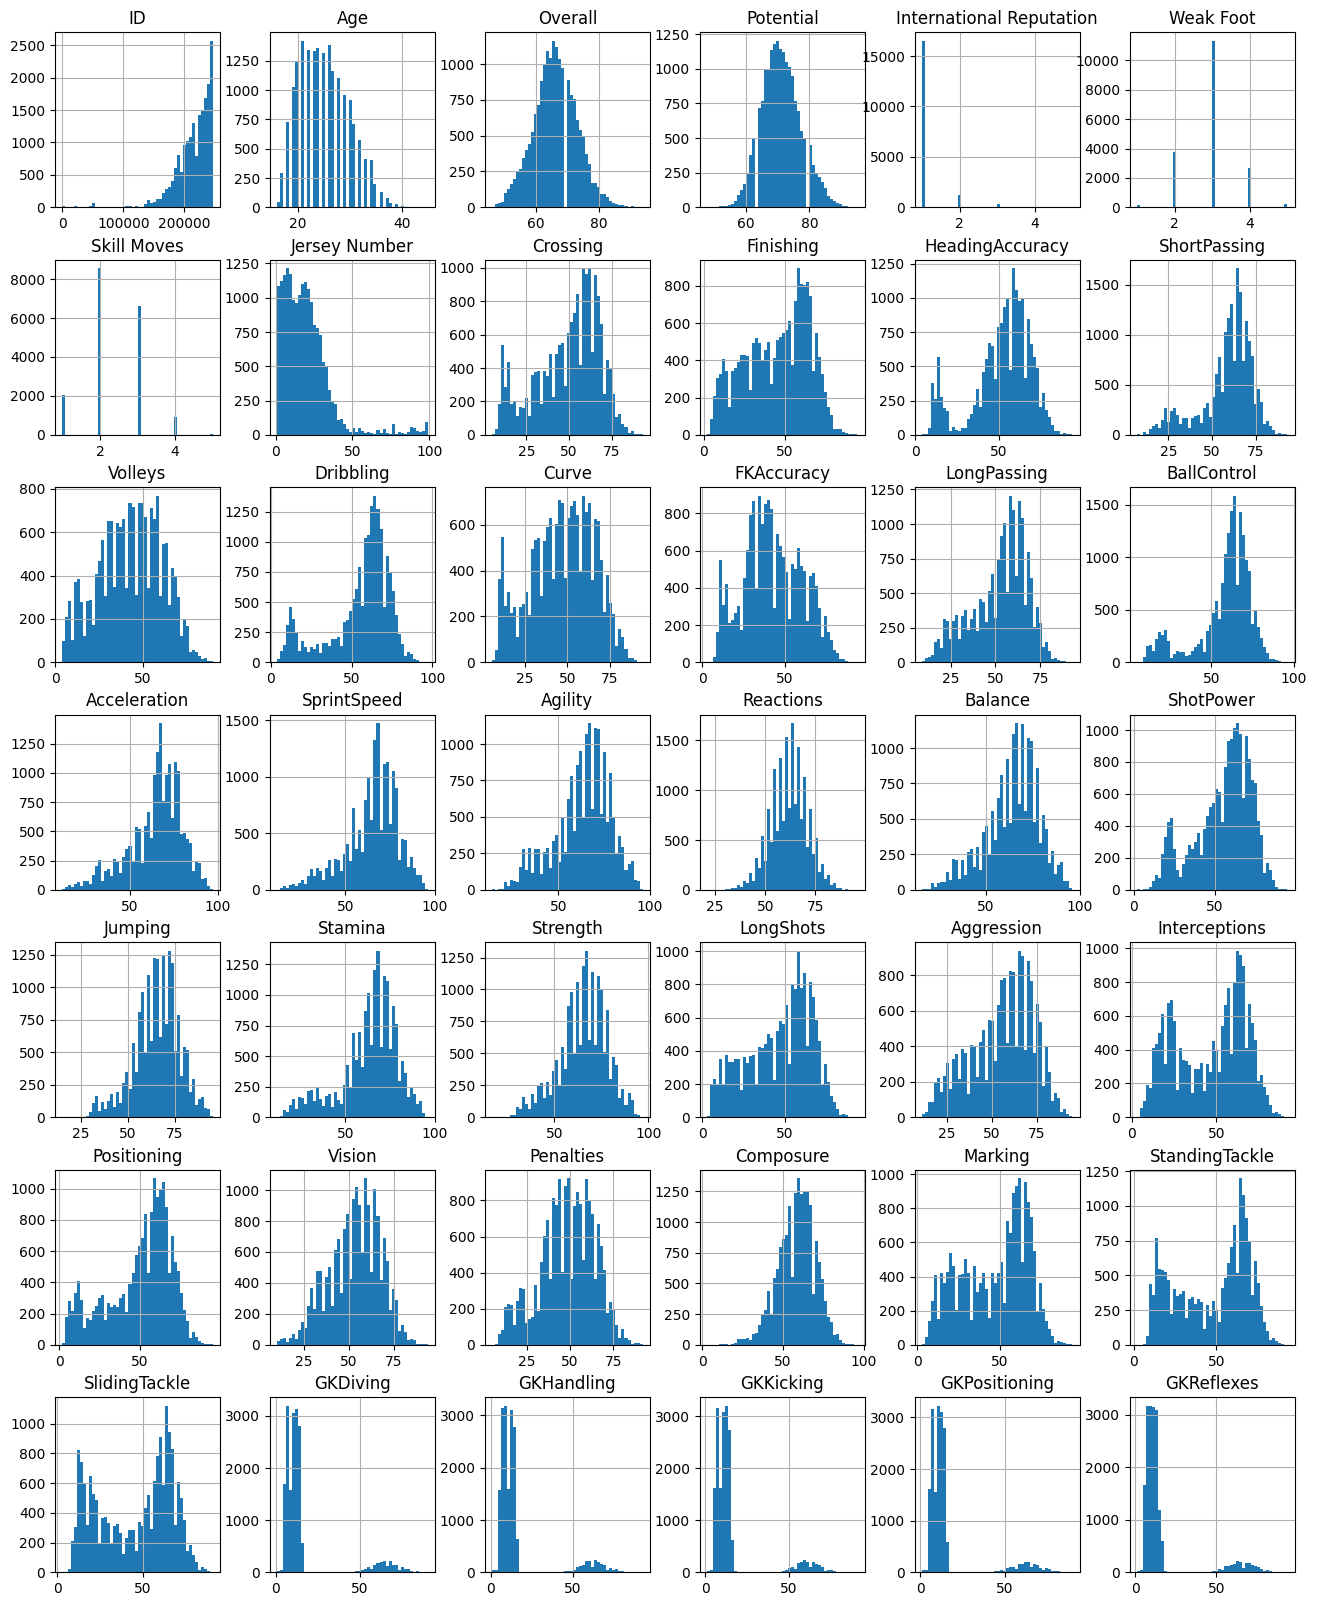

In [6]:
df.hist(figsize=(16, 20), bins=50)

In [13]:
num_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = num_df.corr()
print(corr_matrix["Overall"].sort_values(ascending=False))

Overall                     1.000000
Reactions                   0.850045
Composure                   0.727655
Potential                   0.660939
ShortPassing                0.502550
International Reputation    0.499491
Vision                      0.498894
LongPassing                 0.483909
BallControl                 0.460197
Age                         0.452350
ShotPower                   0.441118
LongShots                   0.420795
Curve                       0.419491
Skill Moves                 0.414463
FKAccuracy                  0.396892
Aggression                  0.395470
Crossing                    0.394972
Volleys                     0.391338
Dribbling                   0.372426
Stamina                     0.365656
Positioning                 0.356493
Strength                    0.349326
Penalties                   0.341429
HeadingAccuracy             0.340776
Finishing                   0.332515
Interceptions               0.321326
Marking                     0.286505
A

/var/folders/v_/gqb7mbln0m7913dtcn63bkl00000gp/T/ipykernel_81419/3766810189.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_overall.values, y=corr_with_overall.index, palette='coolwarm')


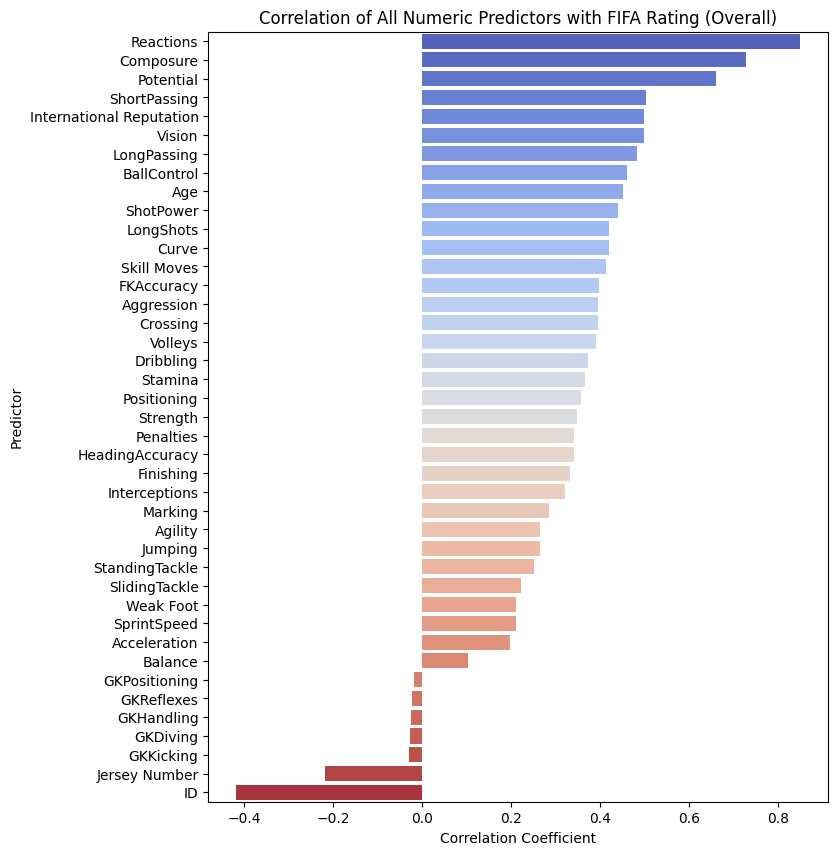

In [14]:
corr_with_overall = corr_matrix['Overall'].drop('Overall').sort_values(ascending=False)
plt.figure(figsize=(8,10))
sns.barplot(x=corr_with_overall.values, y=corr_with_overall.index, palette='coolwarm')
plt.title("Correlation of All Numeric Predictors with FIFA Rating (Overall)")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Predictor")
plt.show()


# Knn


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
data = pd.read_csv('../datasets/cleaned.csv')
print(f"Dataset shape: {data.shape}")

target_col = 'Overall'

numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
feature_cols = [col for col in numeric_cols if col != target_col]

data = data.dropna(subset=[target_col])
X = data[feature_cols]
y = data[target_col]

X = X.fillna(X.median())

print(f"Number of numeric features: {len(feature_cols)}")

Dataset shape: (18207, 56)
Number of numeric features: 46


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor())
])

param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]
}

knn_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=1
)

knn_search.fit(X_train, y_train)

print('Best params:', knn_search.best_params_)
print('Best CV RMSE:', (-knn_search.best_score_) ** 0.5)

Best params: {'knn__n_neighbors': 11, 'knn__p': 1, 'knn__weights': 'distance'}
Best CV RMSE: 1.6284445508559864


In [9]:
best_model = knn_search.best_estimator_
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Test MAE: {mae:.3f}")
print(f"Test RMSE: {rmse:.3f}")
print(f"Test R^2: {r2:.3f}")

Test MAE: 1.241
Test RMSE: 1.588
Test R^2: 0.946


In [11]:
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
nested_mse_scores = []

for train_idx, val_idx in outer_cv.split(X, y):
    X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

    inner_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring='neg_mean_squared_error',
        cv=5,
        n_jobs=-1
    )
    inner_search.fit(X_train_cv, y_train_cv)

    preds_outer = inner_search.predict(X_val_cv)
    mse_outer = mean_squared_error(y_val_cv, preds_outer)
    nested_mse_scores.append(mse_outer)

print(f"Nested CV MSE per fold: {nested_mse_scores}")
print(f"Nested CV Mean MSE: {np.mean(nested_mse_scores)}")
print(f"Nested CV RMSE: {np.sqrt(np.mean(nested_mse_scores))}")

Nested CV MSE per fold: [2.5190814047346426, 2.58830053869779, 2.5733927146611624, 2.7032762222869007, 2.712889402926573]
Nested CV Mean MSE: 2.6193880566614136
Nested CV RMSE: 1.6184523646562519


# Neural Net


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor


In [3]:
data = pd.read_csv('datasets/cleaned.csv')

target_col = 'Overall'
y = data[target_col]
mask = y.notna()
data = data[mask].copy()
y = y[mask]
drop_cols = [
    'ID', 'Name', 'Joined', 'Contract Valid Until',
    'Wage', 'Value', 'Release Clause',
    target_col
]
X = data.drop(columns=[c for c in drop_cols if c in data.columns])
categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.columns.difference(categorical_cols)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols),
    ],
    remainder='drop'
)


In [4]:
mlp = MLPRegressor(
    random_state=42,
    max_iter=200,
    early_stopping=True,
    n_iter_no_change=10,
)

model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('mlp', mlp)
])

param_grid = {
    'mlp__hidden_layer_sizes': [(128, 64), (256, 128)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': [1e-4, 1e-3],
    'mlp__learning_rate_init': [0.001, 0.005],
    'mlp__batch_size': ['auto', 128]
}

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

grid = GridSearchCV(
    model,
    param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    n_jobs=-1,
    refit=True,
)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_params = grid.best_params_
best_cv_rmse = (-grid.best_score_) ** 0.5
print("Best MLP params:", best_params)
print(f"Best CV RMSE: {best_cv_rmse:.3f}")

y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
print(f"Train MSE:  {train_mse:.3f}")
print(f"Test MSE:   {test_mse:.3f}")
print(f"Test RMSE:  {np.sqrt(test_mse)}")
print(f"Test R2:    {r2_score(y_test, y_pred_test)}")


/Users/bunjiroyamada/Downloads/fifadata/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/bunjiroyamada/Downloads/fifadata/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/bunjiroyamada/Downloads/fifadata/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/bunjiroyamada/Downloads/fifadata/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the 

Best MLP params: {'mlp__activation': 'relu', 'mlp__alpha': 0.001, 'mlp__batch_size': 'auto', 'mlp__hidden_layer_sizes': (256, 128), 'mlp__learning_rate_init': 0.001}
Best CV RMSE: 0.909
Train MSE:  0.224
Test MSE:   0.599
Test RMSE:  0.773902956839266
Test R2:    0.9871219843253025


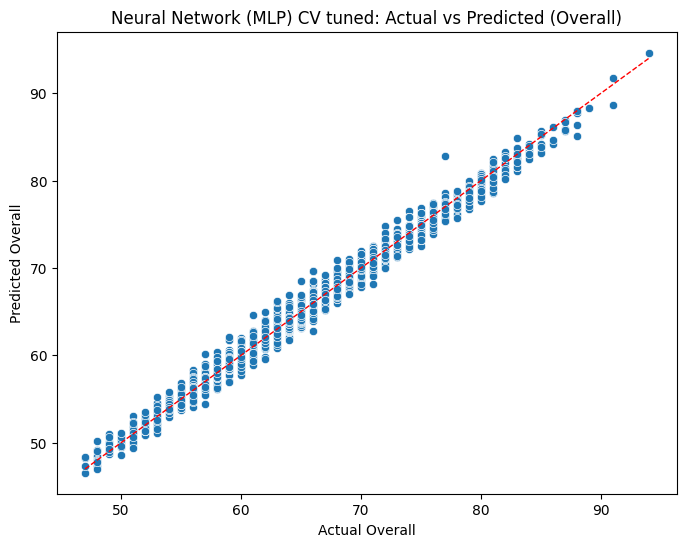

In [5]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_test)
plt.xlabel("Actual Overall")
plt.ylabel("Predicted Overall")
plt.title("Neural Network (MLP) CV tuned: Actual vs Predicted (Overall)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1)
plt.show()


In [6]:
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
nested_mse_scores = []

for train_idx, val_idx in outer_cv.split(X, y):
    X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

    inner_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring='neg_mean_squared_error',
        cv=3,
        n_jobs=-1,
        refit=True,
    )
    inner_search.fit(X_train_cv, y_train_cv)

    preds_outer = inner_search.predict(X_val_cv)
    mse_outer = mean_squared_error(y_val_cv, preds_outer)
    nested_mse_scores.append(mse_outer)
    
nested_mse_scores = np.array(nested_mse_scores)
nested_rmse = np.sqrt(nested_mse_scores.mean())

print(f"Nested CV MSE per fold: {nested_mse_scores.tolist()}")
print(f"Nested CV Mean MSE: {nested_mse_scores.mean()}")
print(f"Nested CV RMSE: {nested_rmse}")


/Users/bunjiroyamada/Downloads/fifadata/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/bunjiroyamada/Downloads/fifadata/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/bunjiroyamada/Downloads/fifadata/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/bunjiroyamada/Downloads/fifadata/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the 

Nested CV MSE per fold: [0.9338295347517495, 0.5452402965890512, 0.6785145052050362, 0.7262404420190695, 0.8913701240478075]
Nested CV Mean MSE: 0.7550389805225428
Nested CV RMSE: 0.8689297903297727


# Random Forest


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

Best RF params: {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__n_estimators': 150}
Best CV RMSE: 1.037
Train MSE:  0.147
Test MSE:   0.989
Test RMSE:  0.994
Test R2:    0.979


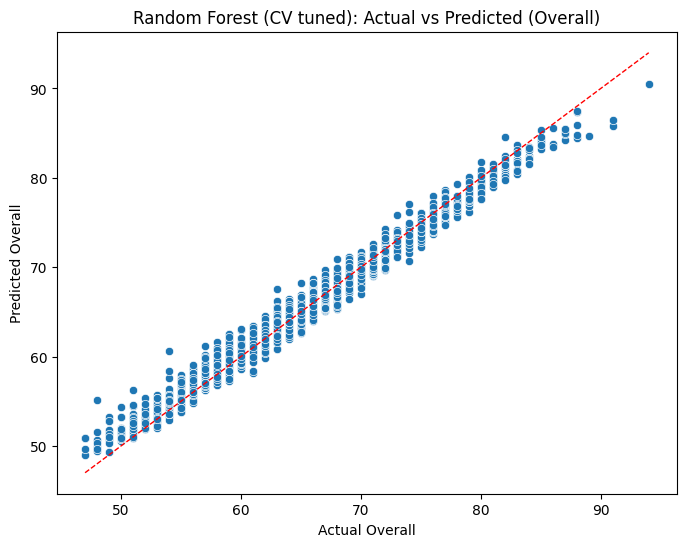

In [18]:
data = pd.read_csv('datasets/cleaned.csv')

target_col = 'Overall'
y = data[target_col]

mask = y.notna()
data = data[mask].copy()
y = y[mask]

drop_cols = [
    'ID', 'Name', 'Joined', 'Contract Valid Until',
    'Wage', 'Value', 'Release Clause',
    target_col
]
X = data.drop(columns=[c for c in drop_cols if c in data.columns])

categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.columns.difference(categorical_cols)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols),
    ],
    remainder='drop'
)

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('rf', rf)
])

# Hyperparameter grid tuned via CV
param_grid = {
    'rf__n_estimators': [150],      # fixed
    'rf__max_depth': [20, None],    # small sweep
    'rf__max_features': ['sqrt'],   # fastest
}

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

grid = GridSearchCV(
    model,
    param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    refit=True,
)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_params = grid.best_params_
best_cv_rmse = (-grid.best_score_) ** 0.5
print("Best RF params:", best_params)
print(f"Best CV RMSE: {best_cv_rmse:.3f}")

# Evaluate tuned model
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
print(f"Train MSE:  {train_mse:.3f}")
print(f"Test MSE:   {test_mse:.3f}")
print(f"Test RMSE:  {np.sqrt(test_mse):.3f}")
print(f"Test R2:    {r2_score(y_test, y_pred_test):.3f}")

# Plot predictions vs actual
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_test)
plt.xlabel("Actual Overall")
plt.ylabel("Predicted Overall")
plt.title("Random Forest (CV tuned): Actual vs Predicted (Overall)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1)
plt.show()


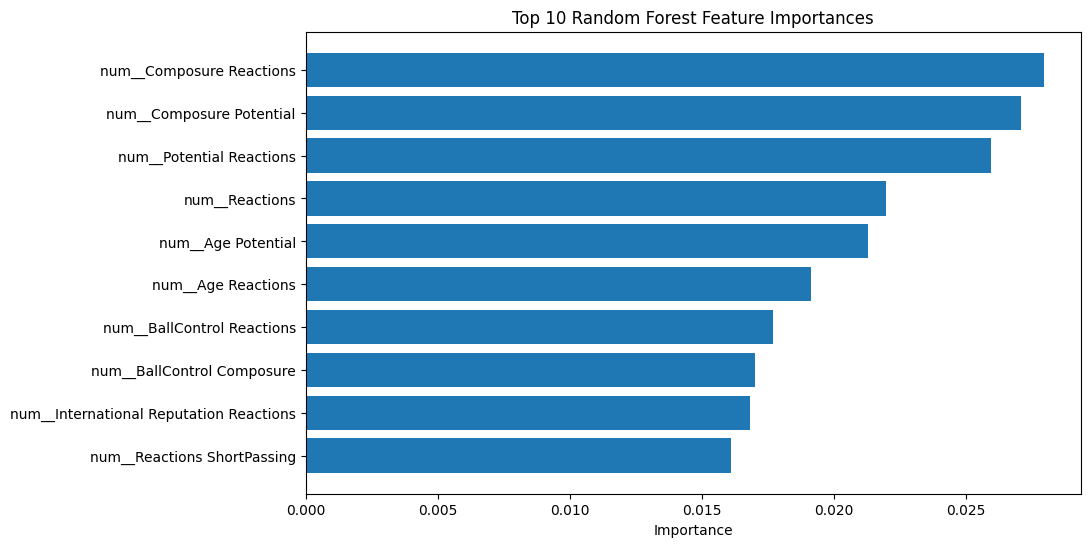

In [21]:
importances = best_model.named_steps['rf'].feature_importances_
columns = best_model.named_steps['preprocess'].get_feature_names_out()

feature_importance_df = pd.DataFrame({
    'feature': columns,
    'importance': importances
}).sort_values('importance', ascending=False)

top10 = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10['feature'], top10['importance'])
plt.xlabel("Importance")
plt.title("Top 10 Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.show()

In [19]:
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
nested_mse_scores = []

for train_idx, val_idx in outer_cv.split(X, y):
    X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

    inner_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring='neg_mean_squared_error',
        cv=5,
        n_jobs=-1,
        refit=True,
    )
    inner_search.fit(X_train_cv, y_train_cv)

    preds_outer = inner_search.predict(X_val_cv)
    mse_outer = mean_squared_error(y_val_cv, preds_outer)
    nested_mse_scores.append(mse_outer)

print(f"Nested CV MSE per fold: {nested_mse_scores}")
print(f"Nested CV Mean MSE: {np.mean(nested_mse_scores):.3f}")
print(f"Nested CV RMSE: {np.sqrt(np.mean(nested_mse_scores)):.3f}")


Nested CV MSE per fold: [0.9886620660198914, 1.0274588199402037, 0.9768260978363698, 1.0203883914675456, 1.0697930361011934]
Nested CV Mean MSE: 1.017
Nested CV RMSE: 1.008


# Ridge


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV
from sklearn.impute import KNNImputer

/Users/bunjiroyamada/Library/Python/3.9/lib/python/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Optimal alpha: 4.7149
Best CV RMSE: 0.891
Train MSE: 0.637
Test MSE: 0.767
Test RMSE: 0.876
Test R2: 0.984


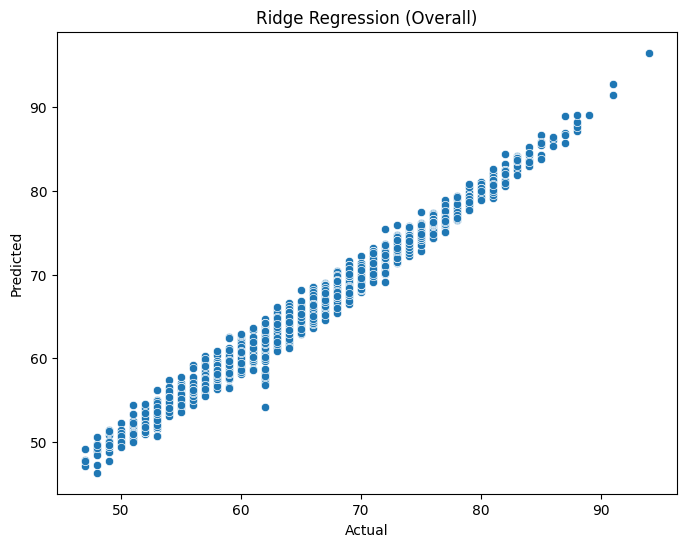

In [2]:
data = pd.read_csv('../datasets/cleaned.csv')

target_col = 'Overall'  
y = data[target_col]

mask = y.notna()
data = data[mask].copy()
y = y[mask]

drop_cols = [
    'ID', 'Name', 'Joined', 'Contract Valid Until',
    'Wage', 'Value', 'Release Clause',
    target_col
]
X = data.drop(columns=[c for c in drop_cols if c in data.columns])

categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.columns.difference(categorical_cols)

numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols),
    ],
    remainder='drop'
)

alphas = np.logspace(-3, 3, 50)
model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('ridge', Ridge())
])
param_grid = {'ridge__alpha': alphas}

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

grid = GridSearchCV(
    model, param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    refit=True
)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_alpha = grid.best_params_['ridge__alpha']
best_cv_rmse = (-grid.best_score_) ** 0.5
print(f"Optimal alpha: {best_alpha:.4f}")
print(f"Best CV RMSE: {best_cv_rmse:.3f}")

y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
print(f"Train MSE: {train_mse:.3f}")
print(f"Test MSE: {test_mse:.3f}")
print(f"Test RMSE: {np.sqrt(test_mse):.3f}")
print(f"Test R2: {r2_score(y_test, y_pred_test):.3f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_test)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Ridge Regression ({target_col})")
plt.show()

In [3]:
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)

nested_mse_scores = []

for train_idx, val_idx in outer_cv.split(X, y):
    X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

    model_cv = Pipeline([
        ('preprocess', preprocess),
        ('ridge', RidgeCV(alphas=alphas, scoring='neg_mean_squared_error', cv=5))
    ])

    model_cv.fit(X_train_cv, y_train_cv)

    preds_outer = model_cv.predict(X_val_cv)
    mse_outer = mean_squared_error(y_val_cv, preds_outer)
    nested_mse_scores.append(mse_outer)

print(f"Nested CV MSE per fold: {nested_mse_scores}")
print(f"Nested CV Mean MSE: {np.mean(nested_mse_scores)}")
print(f"Nested CV RMSE: {np.sqrt(np.mean(nested_mse_scores))}")

Nested CV MSE per fold: [0.7434403149529041, 0.7745747363479721, 0.812006593984276, 0.7739014273899705, 0.8228178355402204]
Nested CV Mean MSE: 0.7853481816430685
Nested CV RMSE: 0.886198725818915


# Xgboost


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

In [24]:
data = pd.read_csv('datasets/cleaned.csv')
target_col = 'Overall'
y = data[target_col]
mask = y.notna()
data = data[mask].copy()
y = y[mask]
drop_cols = [
    'ID', 'Name', 'Joined', 'Contract Valid Until',
    'Wage', 'Value', 'Release Clause',
    target_col
]
X = data.drop(columns=[c for c in drop_cols if c in data.columns])

categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.columns.difference(categorical_cols)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)),
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols),
    ],
    remainder='drop'
)

In [25]:
xgb = XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
)

model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('xgb', xgb)
])

param_grid = {
    'xgb__n_estimators': [400, 800],
    'xgb__learning_rate': [0.05, 0.1],
    'xgb__max_depth': [4, 6],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0],
    'xgb__min_child_weight': [1, 5],
    'xgb__reg_lambda': [1.0, 5.0]
}

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

grid = GridSearchCV(
    model,
    param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    refit=True,
)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_params = grid.best_params_
best_cv_rmse = (-grid.best_score_) ** 0.5
print("Best XGB params:", best_params)
print("Best CV RMSE:", best_cv_rmse)

y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
print("Train MSE:" ,train_mse)
print("Test MSE:" ,test_mse)
print(f"Test RMSE:  {np.sqrt(test_mse):.3f}")
print(f"Test R2:    {r2_score(y_test, y_pred_test)}")


KeyboardInterrupt: 

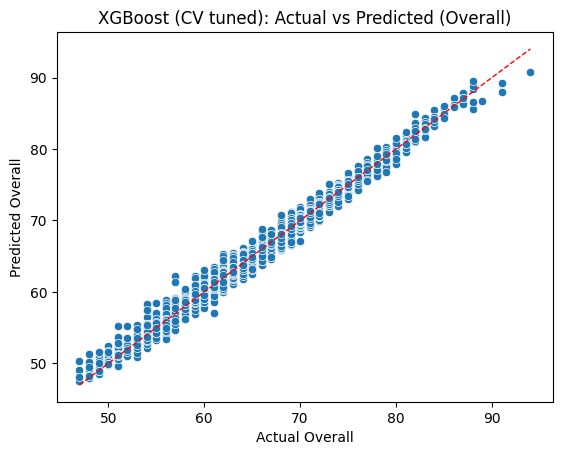

In [10]:
sns.scatterplot(x=y_test, y=y_pred_test)
plt.xlabel("Actual Overall")
plt.ylabel("Predicted Overall")
plt.title("XGBoost (CV tuned): Actual vs Predicted (Overall)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1)
plt.show()


In [11]:
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
nested_mse_scores = []

for train_idx, val_idx in outer_cv.split(X, y):
    X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

    inner_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring='neg_mean_squared_error',
        cv=5,
        n_jobs=-1,
        refit=True,
    )
    inner_search.fit(X_train_cv, y_train_cv)

    preds_outer = inner_search.predict(X_val_cv)
    mse_outer = mean_squared_error(y_val_cv, preds_outer)
    nested_mse_scores.append(mse_outer)

print(f"Nested CV MSE per fold: {nested_mse_scores}")
print(f"Nested CV Mean MSE: {np.mean(nested_mse_scores)}")
print(f"Nested CV RMSE: {np.sqrt(np.mean(nested_mse_scores))}")


Nested CV MSE per fold: [0.6383397579193115, 0.6781249046325684, 0.664589524269104, 0.6458474397659302, 0.6695164442062378]
Nested CV Mean MSE: 0.6592836141586303
Nested CV RMSE: 0.811962815748745


# Data

In [10]:
nested_cv_results = {
    "KNN": 1.6184523646562519,
    "Random Forest": 1.385,
    "Ridge": 0.886198725818915,
    "Neural Net": 0.8689297903297727,
    "XGBoost": 0.811962815748745
}

# Conclusion

In [11]:
import pandas as pd

df_results = pd.DataFrame.from_dict(
    nested_cv_results, orient='index', columns=['Nested_CV_RMSE']
)
df_results

,Nested_CV_RMSE
KNN,1.618452
Random Forest,1.385000
Ridge,0.886199
Neural Net,0.868930
XGBoost,0.811963


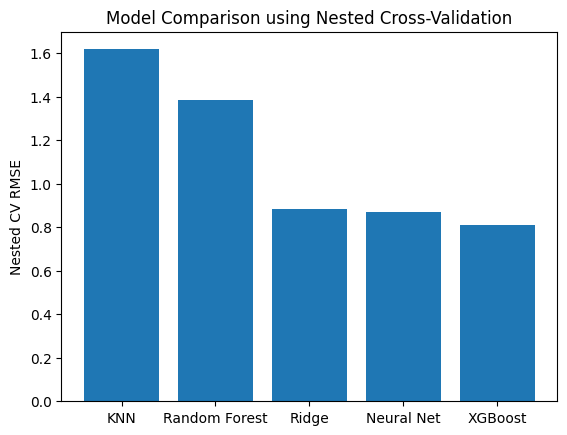

In [12]:
import matplotlib.pyplot as plt

plt.bar(df_results.index, df_results['Nested_CV_RMSE'])
plt.ylabel("Nested CV RMSE")
plt.title("Model Comparison using Nested Cross-Validation")
plt.show()